# GPT Training Experiment: Stride 128 on 5M Shakespeare

## Configuration
- **Data**: 5M chars (Shakespeare single file)
- **Context Length**: 128
- **Stride**: 128 (0% overlap)
- **Batch Size**: 256
- **Epochs**: 20
- **Hardware**: A100 GPU

## Training Results

### Loss Progression
| Epoch | Train Loss | Val Loss | Gap | Perplexity |
|-------|------------|----------|-----|-------------|
| 1 | 9.928 | 9.987 | +0.059 | 20,488 |
| 2 | 5.081 | 5.239 | +0.157 | 160.9 |
| 5 | 4.168 | 4.453 | +0.285 | 64.6 |
| 10 | 3.567 | 4.006 | +0.440 | 35.4 |
| 13 | 3.299 | 3.911 | +0.612 | 27.1 |
| 15 | 3.267 | 3.857 | +0.590 | 26.2 |
| 18 | 3.135 | 3.820 | +0.685 | 23.0 |
| 20 | 3.046 | 3.790 | +0.745 | 21.0 |

### Final Metrics
- **Final Train Loss**: 3.046
- **Final Val Loss**: 3.790
- **Train Perplexity**: 21.0
- **Val Perplexity**: 44.3
- **Overfitting Gap**: +0.745 (widening)

## Comparison: Stride 64 vs Stride 128

| Metric | Stride 64 (Baseline) | Stride 128 (This run) |
|--------|---------------------|----------------------|
| Train Loss | 2.577 | 3.046 |
| Val Loss | 2.943 | 3.790 |
| Gap | +0.366 | +0.745 |
| Perplexity | 13.2 | 21.0 |
| Samples | ~31,000 | ~15,500 |

## Key Observations

### Worse performance across all metrics:
- **+0.379 higher val loss** (2.943 → 3.790)
- **Gap doubled** (0.366 → 0.745) - more overfitting
- **Perplexity worse** (13.2 → 21.0)

### Why stride 128 failed:
1. **Half the training samples** (15,500 vs 31,000)
2. **No overlap** means each token appears in fewer contexts
3. **Underfitting** from less data diversity
4. **Model sees fewer patterns** → higher loss

### Generation quality:
- Repetitive ("I am a man, I'll be a man")
- Short, fragmented responses
- Less coherent than baseline

## Conclusion
**Stride 64 is optimal for 5M chars.** Stride 128 reduces samples too much, causing:
- Higher final loss (+0.5)
- Wider overfitting gap (2x)
- Poorer generation quality

## Recommendation
For 5M data: **Always use stride 64** (50% overlap). Only use stride 128 with 20M+ chars.

```python
# Best config for 5M data
CONTEXT_LENGTH = 128
STRIDE = 64  # NOT 128
BATCH_SIZE = 256

In [ ]:
!pip install tiktoken datasets -q

In [114]:
import re, torch, tiktoken
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [115]:
import urllib.request

# Single working source (5M chars)
url = 'https://ocw.mit.edu/ans7870/6/6.006/s08/lecturenotes/files/t8.shakespeare.txt'
urllib.request.urlretrieve(url, 'shakespeare_full.txt')

with open('shakespeare_full.txt', 'r', encoding='utf-8') as f:
    text = f.read()

text = text[5000:-5000]
split = int(0.9 * len(text))
raw_text = text[:split]
val_text = text[split:]

print(f"Total: {len(text):,} chars")

Total: 5,448,199 chars


In [116]:
tokenizer = tiktoken.get_encoding('gpt2')
print(f'vocab size: {tokenizer.n_vocab:,}')

vocab size: 50,257


In [117]:
CONTEXT_LENGTH = 128      # Increased from 128
STRIDE = 128              # Keep stride = context/2
BATCH_SIZE = 256         # Increased from 256
num_workers = 4           # Conservative for stability

In [118]:
class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, context_length, stride):
        ids = tokenizer.encode(txt)
        self.inputs  = [torch.tensor(ids[i:i+context_length])     for i in range(0, len(ids)-context_length, stride)]
        self.targets = [torch.tensor(ids[i+1:i+context_length+1]) for i in range(0, len(ids)-context_length, stride)]
    def __len__(self):          return len(self.inputs)
    def __getitem__(self, idx): return self.inputs[idx], self.targets[idx]

train_ds     = GPTDataset(raw_text, tokenizer, CONTEXT_LENGTH, STRIDE)
val_ds       = GPTDataset(val_text, tokenizer, CONTEXT_LENGTH, STRIDE)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, num_workers=4, pin_memory=True)

print(f'train: {len(train_ds):,} samples | {len(train_loader):,} batches')
print(f'val  : {len(val_ds):,} samples | {len(val_loader):,} batches')


train: 12,982 samples | 50 batches
val  : 1,451 samples | 6 batches


In [119]:
GPT_CONFIG = {
    'vocab_size':     50257,
    'context_length': 128,  # Updated
    'emb_dim':        384,
    'n_heads':        6,
    'n_layers':       6,
    'drop_rate':      0.2,
    'qkv_bias':       False,
}

In [120]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + 1e-5) + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x + 0.044715 * x**3)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4*cfg['emb_dim']),
            GELU(),
            nn.Linear(4*cfg['emb_dim'], cfg['emb_dim'])
        )
    def forward(self, x): return self.net(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d_in, d_out   = cfg['emb_dim'], cfg['emb_dim']
        self.n_heads  = cfg['n_heads']
        self.head_dim = d_out // self.n_heads
        assert d_out % self.n_heads == 0
        self.Wq      = nn.Linear(d_in, d_out, bias=cfg['qkv_bias'])
        self.Wk      = nn.Linear(d_in, d_out, bias=cfg['qkv_bias'])
        self.Wv      = nn.Linear(d_in, d_out, bias=cfg['qkv_bias'])
        self.proj    = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(cfg['drop_rate'])
        self.register_buffer('mask', torch.triu(torch.ones(cfg['context_length'], cfg['context_length']), diagonal=1))
    def forward(self, x):
        b, t, _ = x.shape
        def split(w): return w(x).view(b, t, self.n_heads, self.head_dim).transpose(1, 2)
        Q, K, V  = split(self.Wq), split(self.Wk), split(self.Wv)
        scores   = Q @ K.transpose(2, 3) / self.head_dim**0.5
        scores.masked_fill_(self.mask.bool()[:t, :t], float('-inf'))
        weights  = self.dropout(torch.softmax(scores, dim=-1))
        out      = (weights @ V).transpose(1, 2).contiguous().view(b, t, -1)
        return self.proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn  = MultiHeadAttention(cfg)
        self.ff    = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop  = nn.Dropout(cfg['drop_rate'])
    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop    = nn.Dropout(cfg['drop_rate'])
        self.blocks  = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])
        self.norm    = LayerNorm(cfg['emb_dim'])
        self.head    = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)
    def forward(self, idx):
        b, t = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(t, device=idx.device))
        x = self.drop(x)
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x)

torch.manual_seed(123)
model   = GPTModel(GPT_CONFIG).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'params: {n_params:,} | size: {n_params*4/1024**2:.1f} MB')


params: 49,287,168 | size: 188.0 MB


In [121]:
TRAIN_CONFIG = {
    'learning_rate': 3e-4,
    'weight_decay':  0.2,     # was 0.1
    'num_epochs':    20,      # was 10
    'eval_freq':     20,
    'eval_iter':     5,
    'start_context': 'To be or not to be',
}

In [122]:
def encode(text):
    return torch.tensor(tokenizer.encode(text, allowed_special={'<|endoftext|>'})).unsqueeze(0)

def decode(ids):
    return tokenizer.decode(ids.squeeze(0).tolist())

def loss_batch(x, y, model, device):
    x, y = x.to(device), y.to(device)
    return nn.functional.cross_entropy(model(x).flatten(0,1), y.flatten())

def loss_loader(loader, model, device, n_batches=None):
    n = min(n_batches or len(loader), len(loader))
    return sum(loss_batch(x, y, model, device).item() for i,(x,y) in enumerate(loader) if i < n) / n

@torch.no_grad()
def evaluate(model, train_loader, val_loader, device, n):
    model.eval()
    tl = loss_loader(train_loader, model, device, n)
    vl = loss_loader(val_loader,   model, device, n)
    model.train()
    return tl, vl

def train(model, train_loader, val_loader, optimizer, device, cfg):
    train_losses, val_losses, tokens_seen_log = [], [], []
    tokens_seen, step = 0, -1
    for epoch in range(cfg['num_epochs']):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            loss_batch(x, y, model, device).backward()
            optimizer.step()
            tokens_seen += x.numel()
            step += 1
            if step % cfg['eval_freq'] == 0:
                tl, vl = evaluate(model, train_loader, val_loader, device, cfg['eval_iter'])
                train_losses.append(tl)
                val_losses.append(vl)
                tokens_seen_log.append(tokens_seen)
                print(f'ep {epoch+1:02d} | step {step:05d} | train {tl:.3f} | val {vl:.3f} | gap {vl-tl:+.3f} | ppl {torch.exp(torch.tensor(tl)):.1f}')
        model.eval()
        with torch.no_grad():
            out = generate(model, encode(cfg['start_context']).to(device), max_new_tokens=30, context_size=GPT_CONFIG['context_length'])
        print(f'  >> {decode(out.cpu())}\n')
        model.train()
    return train_losses, val_losses, tokens_seen_log


In [123]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None):
    model.eval()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])[:, -1, :]
        if top_k is not None:
            top_vals, _ = torch.topk(logits, top_k)
            logits = torch.where(logits < top_vals[:, -1:], torch.tensor(float('-inf')).to(logits.device), logits)
        if temperature > 0.0:
            probs    = torch.softmax(logits / temperature, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [124]:
torch.manual_seed(123)

model     = GPTModel(GPT_CONFIG).to(device)


# torch.set_float32_matmul_precision('high')  # TF32 for A100           # JIT compile

optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CONFIG['learning_rate'], weight_decay=TRAIN_CONFIG['weight_decay'])
train_losses, val_losses, tokens_seen_log = train(model, train_loader, val_loader, optimizer, device, TRAIN_CONFIG)


ep 01 | step 00000 | train 9.928 | val 9.987 | gap +0.059 | ppl 20488.3
ep 01 | step 00020 | train 6.118 | val 6.253 | gap +0.135 | ppl 453.8
ep 01 | step 00040 | train 5.354 | val 5.468 | gap +0.115 | ppl 211.4
  >> To be or not to be,
                            

ep 02 | step 00060 | train 5.188 | val 5.315 | gap +0.127 | ppl 179.2
ep 02 | step 00080 | train 5.081 | val 5.239 | gap +0.157 | ppl 160.9
  >> To be or not to be,
                            

ep 03 | step 00100 | train 5.054 | val 5.166 | gap +0.113 | ppl 156.6
ep 03 | step 00120 | train 4.893 | val 5.068 | gap +0.175 | ppl 133.3
ep 03 | step 00140 | train 4.753 | val 4.947 | gap +0.194 | ppl 115.9
  >> To be or not to be
                             

ep 04 | step 00160 | train 4.649 | val 4.827 | gap +0.178 | ppl 104.4
ep 04 | step 00180 | train 4.472 | val 4.715 | gap +0.244 | ppl 87.5
  >> To be or not to be
                             

ep 05 | step 00200 | train 4.388 | val 4.614 | gap +0.226 | ppl 80.5
ep 05 | st

In [130]:
BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

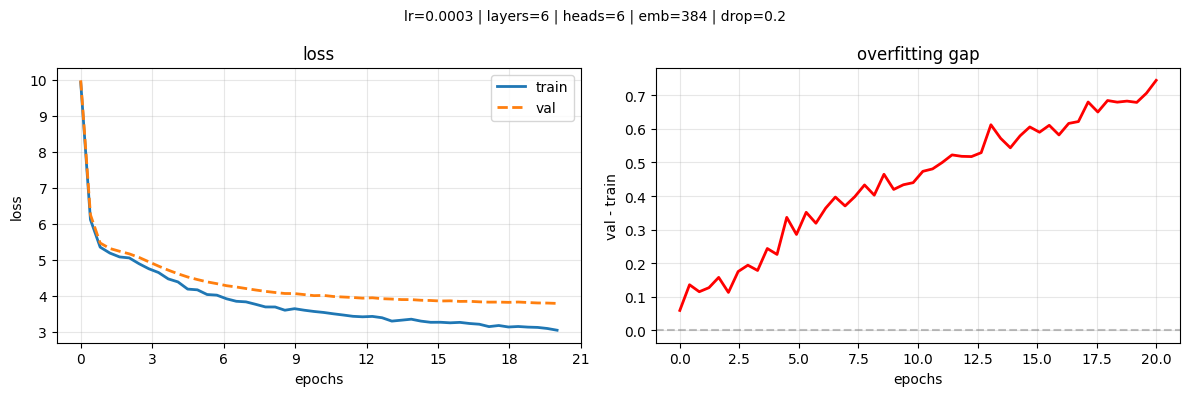

final train loss: 3.046 | ppl: 21.0
final val   loss: 3.790 | ppl: 44.3


In [131]:
epochs_x = torch.linspace(0, TRAIN_CONFIG['num_epochs'], len(train_losses))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_x, train_losses, label='train', linewidth=2)
axes[0].plot(epochs_x, val_losses,   label='val',   linewidth=2, linestyle='--')
axes[0].set_xlabel('epochs'); axes[0].set_ylabel('loss'); axes[0].set_title('loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
gap = [v-t for t,v in zip(train_losses, val_losses)]
axes[1].plot(epochs_x, gap, color='red', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('epochs'); axes[1].set_ylabel('val - train'); axes[1].set_title('overfitting gap')
axes[1].grid(alpha=0.3)
plt.suptitle(f"lr={TRAIN_CONFIG['learning_rate']} | layers={GPT_CONFIG['n_layers']} | heads={GPT_CONFIG['n_heads']} | emb={GPT_CONFIG['emb_dim']} | drop={GPT_CONFIG['drop_rate']}", fontsize=10)
plt.tight_layout(); plt.show()
print(f'final train loss: {train_losses[-1]:.3f} | ppl: {torch.exp(torch.tensor(train_losses[-1])):.1f}')
print(f'final val   loss: {val_losses[-1]:.3f} | ppl: {torch.exp(torch.tensor(val_losses[-1])):.1f}')


In [132]:
PROMPT     = 'To be or not to be'
MAX_TOKENS = 40
GEN_CONFIGS = [
    {'label': 'greedy      ', 'temperature': 0.0, 'top_k': None},
    {'label': 'conservative', 'temperature': 0.5, 'top_k': 10},
    {'label': 'balanced    ', 'temperature': 1.0, 'top_k': 25},
    {'label': 'creative    ', 'temperature': 1.5, 'top_k': 50},
    {'label': 'wild        ', 'temperature': 2.0, 'top_k': None},
]
torch.manual_seed(42)
for cfg in GEN_CONFIGS:
    out = generate(model, encode(PROMPT).to(device), max_new_tokens=MAX_TOKENS,
                   context_size=GPT_CONFIG['context_length'],
                   temperature=cfg['temperature'], top_k=cfg['top_k'])
    print(f"[{cfg['label']}] {decode(out.cpu())}")


[greedy      ] To be or not to be so.
                                     
[conservative] To be or not to be so.
    I'll be a man.
  Ham. I'll be glad to my lord.
  Ham. O, for you, sir, I will not be a
[balanced    ] To be or not to be a king.
  CLOWN. I must have some word for that my friend,
    I'll give your worship your leave and mine.

       
[creative    ] To be or not to be a thing from France.
  Prince. You are a mad; come, your master's dead.

         Enter KING, with others

  PRPERO
[wild        ] To be or not to be spiteierness wererie illust singurbedfully of 2008on eye own. Great inscription castle shut on sprung CH beating Column
 woes buysreath back relay wonder pictures pays lowly East territoryicriegers kilometers


In [133]:
torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'config': GPT_CONFIG}, 'gpt_checkpoint.pth')
print('saved: gpt_checkpoint.pth')
checkpoint   = torch.load('gpt_checkpoint.pth', map_location=device)
loaded_model = GPTModel(checkpoint['config']).to(device)
loaded_model.load_state_dict(checkpoint['model_state'])
loaded_model.eval()
print('loaded ok')


saved: gpt_checkpoint.pth
loaded ok


In [134]:
prompts = [
    'What is the nature of man',
    'The king shall rise',
    'I will not yield to',
    'Speak to me of love',
    'Death comes for us',
]

torch.manual_seed(42)
for prompt in prompts:
    out = generate(
        loaded_model,
        encode(prompt).to(device),
        max_new_tokens=50,
        context_size=GPT_CONFIG['context_length'],
        temperature=1.0,
        top_k=25
    )
    print(f"\n[{prompt}]")
    print(decode(out.cpu()))
    print("-" * 50)


[What is the nature of man]
What is the nature of man, the
    the same-like ducats, and his good father,
    Which doth the King.
  MRS. Sir, my lord, it is your Grace?
  MRS. PAGE
--------------------------------------------------

[The king shall rise]
The king shall rise with some reason's mind. If I do not speak.
  LUCIUS. We must needs hear him, then.
  FIRST WATCH. What, I pray you be gone!
  TIMON. Ay, I have a
--------------------------------------------------

[I will not yield to]
I will not yield to thyself.

             Re-enter PAGE

   PEMBROKE. It is gone? I am not to thee.
  LUCIO. It seems not, mad
--------------------------------------------------

[Speak to me of love]
Speak to me of love! I had been the Duke of
     To show my heart, a soldier shall,
     Which I am not to the world with them.
             
--------------------------------------------------

[Death comes for us]
Death comes for us.
  LUCIUS. My good lord, I'll make a kind woman;
    That I do not